# Sunrise Social Club: Exploratory Data Analysis

## Objective:
Analyze cafe sales data to understand product performance, customer behavior, and operational patterns across items, flavors, customization options, and time of day.

## Section 1: Loading the Data & Overview

In [1]:
#importing libraries
import numpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading the data
df = pd.read_csv("../data/processed/sales_merged.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797 entries, 0 to 796
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               797 non-null    object 
 1   Time               797 non-null    object 
 2   Original_Item      797 non-null    object 
 3   Item               797 non-null    object 
 4   Base               458 non-null    object 
 5   Signature_Drink    797 non-null    bool   
 6   Qty                797 non-null    float64
 7   Net_Sales          797 non-null    float64
 8   Size               576 non-null    object 
 9   Cold_Foam          797 non-null    bool   
 10  Flavor             631 non-null    object 
 11  Avg_Temp           797 non-null    int64  
 12  Weather_Condition  797 non-null    object 
 13  Event_Type         797 non-null    object 
 14  Location           797 non-null    object 
dtypes: bool(2), float64(2), int64(1), object(10)
memory usage: 82.6+ KB


,Qty,Net_Sales,Avg_Temp
count,797.000000,797.000000,797.000000
mean,1.129235,7.743312,80.963614
std,0.394193,4.700630,3.833525
min,1.000000,2.000000,75.000000
25%,1.000000,6.000000,79.000000
50%,1.000000,8.000000,82.000000
75%,1.000000,8.000000,84.000000
max,4.000000,75.000000,86.000000


### Exploring Missing Values:

In [3]:
df.isna().sum().sort_values(ascending=False)

Base                 339
Size                 221
Flavor               166
Date                   0
Time                   0
Original_Item          0
Item                   0
Signature_Drink        0
Qty                    0
Net_Sales              0
Cold_Foam              0
Avg_Temp               0
Weather_Condition      0
Event_Type             0
Location               0
dtype: int64

### Data Quality Notes:

Several fields contain missing values due to limitations or errors when operating the point-of-sale system.

- **Base** is missing for a subset of transactions. These values were retained as missing because the true base could not be determined reliably.
- **Size** is missing for some transactions. While size may be partially inferable from pricing, reconstructing it would require assumptions about add-ons and pricing rules, so missing values were retained.
- **Flavor** is missing for transactions where no flavor was added (e.g., plain Cold Brew, Matcha Latte, or Lemonade). These missing values represent valid non-selection rather than data entry errors.
- Core transaction fields (Date, Time, Item, Quantity, and Net Sales) **are** complete and serve as the primary basis for analysis.

In [4]:
df['Base']= df['Base'].fillna('Unknown')
df['Size']= df['Size'].fillna('Unknown')
df['Flavor']= df['Flavor'].fillna('No Flavor')

## Section 2: Univariate Analysis

### 2.1 Sales Overview

In [5]:
print(f'Total Net Sales: ${df["Net_Sales"].sum():,.2f}')
print(f'Total Quantity Sold: {df["Qty"].sum():,}')

Total Net Sales: $6,171.42
Total Quantity Sold: 900.0


In [6]:
df["Net_Sales"].describe()

count    797.000000
mean       7.743312
std        4.700630
min        2.000000
25%        6.000000
50%        8.000000
75%        8.000000
max       75.000000
Name: Net_Sales, dtype: float64

### 2.2 Item Performance (Revenue and Quantity)
This section explores total revenue and total quantity by item to understand whether high-demand products are also high revenue.

In [7]:
items_by_revenue = df.groupby('Item')['Net_Sales'].sum().sort_values(ascending=False)
items_by_revenue

Item
Matcha Latte               3597.42
Cold Brew                  1556.00
Lemonade                    724.00
Modern Fire Pottery Mug     150.00
Sticker                     144.00
Name: Net_Sales, dtype: float64

In [8]:
items_by_quantity = df.groupby('Item')['Qty'].sum().sort_values(ascending=False)
items_by_quantity

Item
Matcha Latte               446.0
Cold Brew                  218.0
Lemonade                   162.0
Sticker                     72.0
Modern Fire Pottery Mug      2.0
Name: Qty, dtype: float64

In [9]:
item_stats = df.groupby("Item").agg(
    Net_Sales=("Net_Sales", "sum"),
    Qty=("Qty", "sum"))

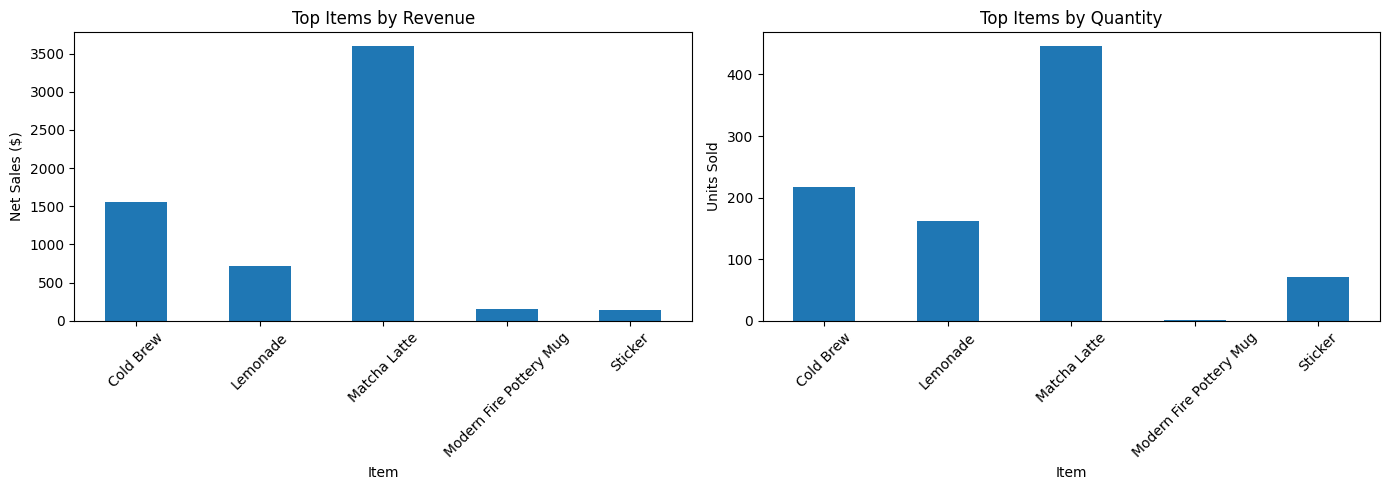

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue
item_stats["Net_Sales"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Top Items by Revenue")
axes[0].set_ylabel("Net Sales ($)")
axes[0].tick_params(axis='x', rotation=45)

# Quantity
item_stats["Qty"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Top Items by Quantity")
axes[1].set_ylabel("Units Sold")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

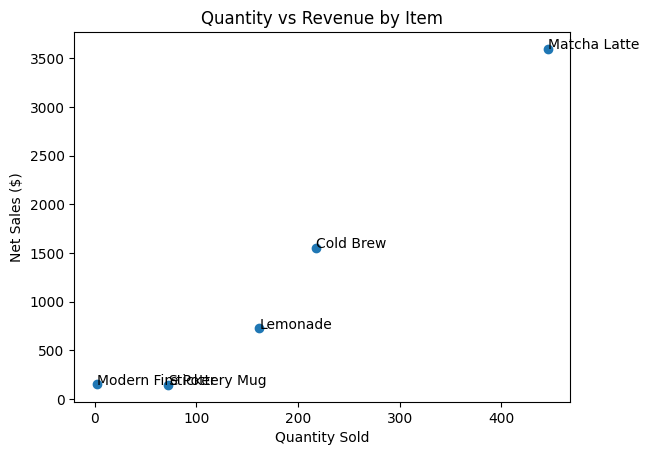

In [11]:
plt.scatter(item_stats["Qty"], item_stats["Net_Sales"])
plt.xlabel("Quantity Sold")
plt.ylabel("Net Sales ($)")
plt.title("Quantity vs Revenue by Item")

for i in item_stats.index:
    plt.text(item_stats.loc[i, "Qty"], item_stats.loc[i, "Net_Sales"], i)

plt.show()

- Matcha Latte dominates both revenue and quantity, indicating it is the core driver of both demand and sales.
- Cold Brew shows high volume but lower revenue efficiency compared to Matcha Latte, suggesting lower price per unit.
- Lemonade performs relatively well in quantity but contributes less revenue, reinforcing its role as a high-volume, lower-margin product.
- Merchandise items (Sticker, Mug) generate revenue despite low volume, highlighting their role as high-margin add-ons rather than core demand drivers.